In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/loan_approval_dataset (1).csv'
df = pd.read_csv(file_path)

# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Mounted at /content/drive
Dataset Shape: (4269, 13)

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Strip whitespace from categorical values
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].str.strip()

# Check for missing values and data types
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# Check for any anomalies in categorical columns
print("\nUnique values in 'education':", df['education'].unique())
print("Unique values in 'self_employed':", df['self_employed'].unique())
print("Unique values in 'loan_status':", df['loan_status'].unique())


Missing Values:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Data Types:
 loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Unique values in 'education': ['Graduate' 'Not Graduate']
Unique values in 'self_employed': ['N

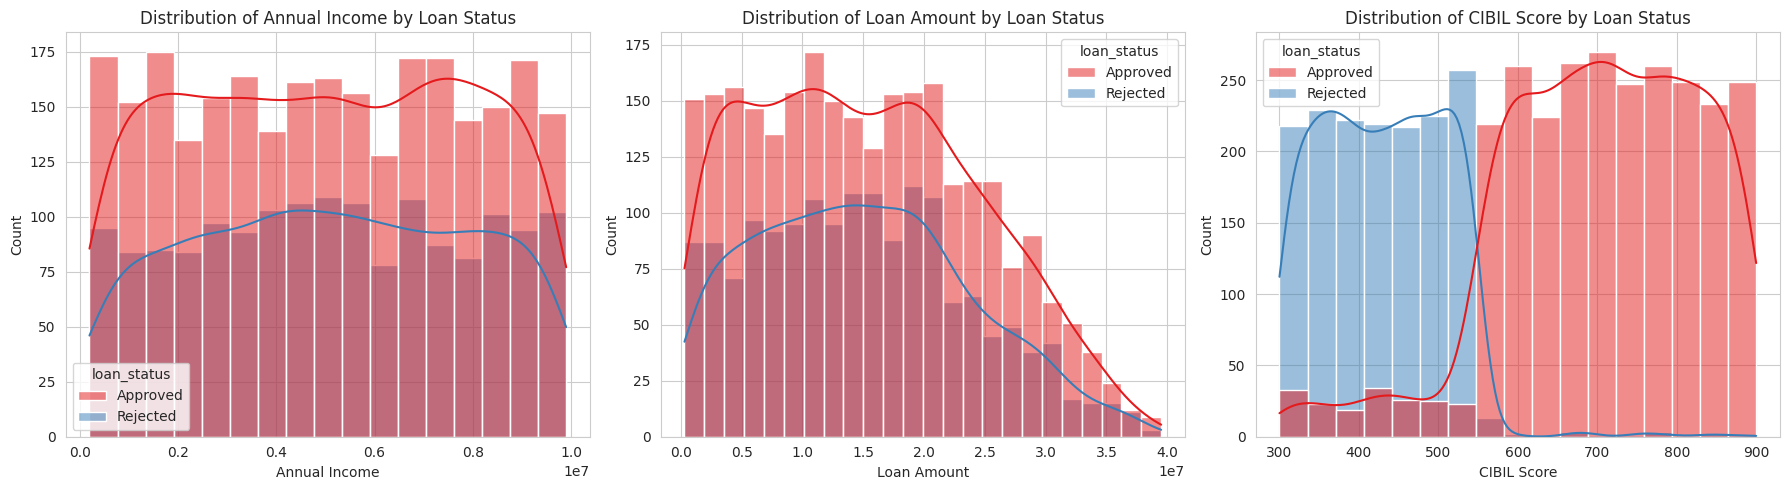

In [6]:
# Set the style for our plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Create a figure to compare distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Income distribution
sns.histplot(data=df, x='income_annum', hue='loan_status', kde=True, ax=axes[0], palette='Set1')
axes[0].set_title('Distribution of Annual Income by Loan Status')
axes[0].set_xlabel('Annual Income')

# 2. Loan Amount distribution
sns.histplot(data=df, x='loan_amount', hue='loan_status', kde=True, ax=axes[1], palette='Set1')
axes[1].set_title('Distribution of Loan Amount by Loan Status')
axes[1].set_xlabel('Loan Amount')

# 3. CIBIL Score distribution
sns.histplot(data=df, x='cibil_score', hue='loan_status', kde=True, ax=axes[2], palette='Set1')
axes[2].set_title('Distribution of CIBIL Score by Loan Status')
axes[2].set_xlabel('CIBIL Score')

plt.tight_layout()
plt.show()

Average CIBIL Score by Loan Status:
 loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64


/tmp/ipykernel_1816/1885371208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='cibil_score', palette='Set1')


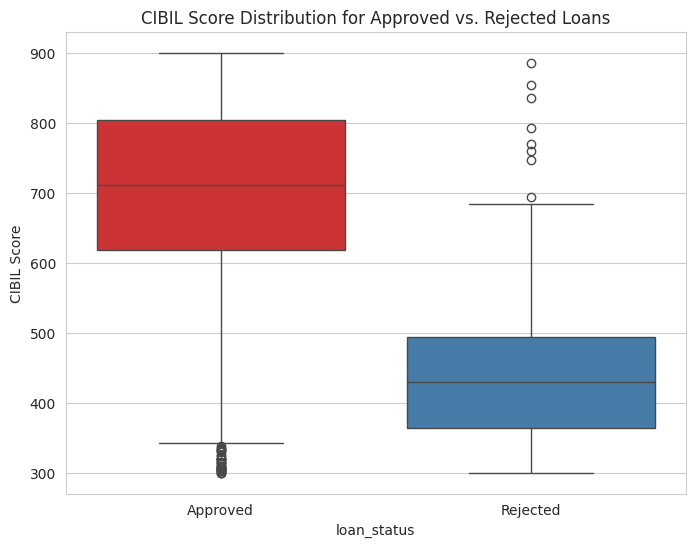

In [7]:
avg_cibil = df.groupby('loan_status')['cibil_score'].mean()
print("Average CIBIL Score by Loan Status:\n", avg_cibil)

# Let's also see a boxplot for a clearer view
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_status', y='cibil_score', palette='Set1')
plt.title('CIBIL Score Distribution for Approved vs. Rejected Loans')
plt.ylabel('CIBIL Score')
plt.show()

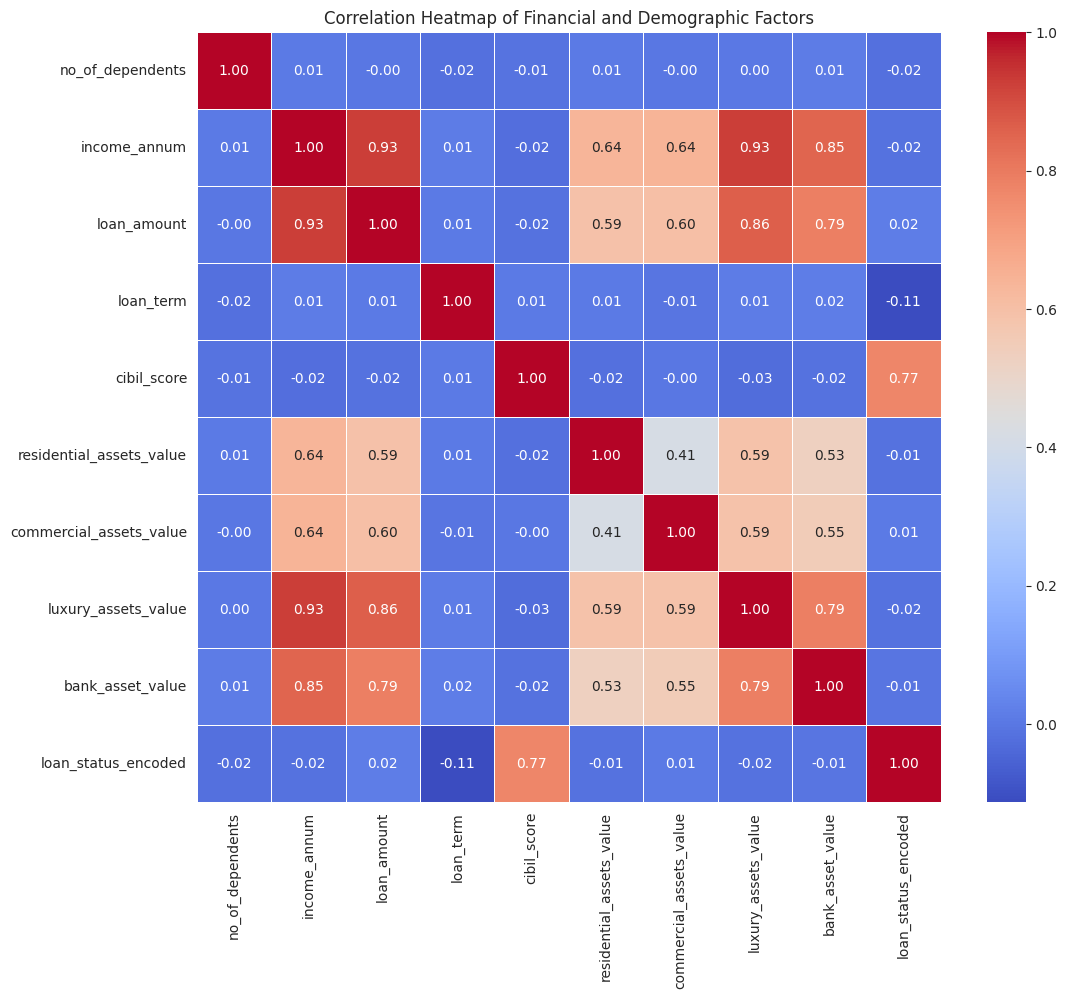


Correlation with Loan Approval (Target Variable):
 loan_status_encoded         1.000000
cibil_score                 0.770518
loan_amount                 0.016150
commercial_assets_value     0.008246
bank_asset_value           -0.006778
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status_encoded, dtype: float64


In [8]:
# Create a copy for correlation analysis
df_corr = df.copy()

# Encode the target variable
df_corr['loan_status_encoded'] = df_corr['loan_status'].map({'Approved': 1, 'Rejected': 0})

# Select numerical columns for correlation
numerical_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                  'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                  'luxury_assets_value', 'bank_asset_value', 'loan_status_encoded']

# Calculate the correlation matrix
corr_matrix = df_corr[numerical_cols].corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Financial and Demographic Factors')
plt.show()

# Focus on correlations with the target variable (loan_status_encoded)
target_corr = corr_matrix['loan_status_encoded'].sort_values(ascending=False)
print("\nCorrelation with Loan Approval (Target Variable):\n", target_corr)

Approval Rate by CIBIL Score Bracket:
 cibil_bracket
300-400    10.227273
400-500    10.919540
500-600    52.251023
600-700    99.433428
700-800    99.455782
800-900    99.568345
Name: loan_status, dtype: float64


/tmp/ipykernel_1816/3894319004.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_rate = df.groupby('cibil_bracket')['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100)


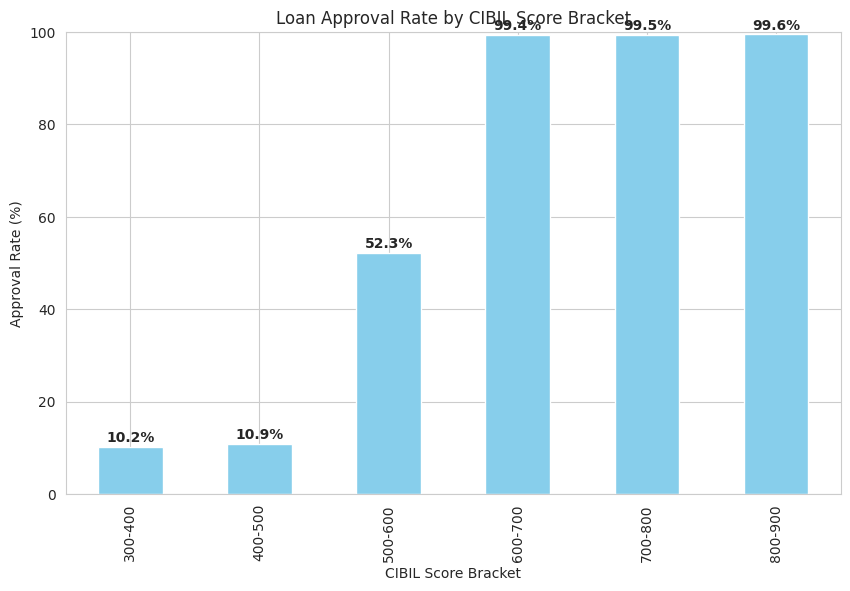

In [9]:
# Create CIBIL score brackets
bins = [300, 400, 500, 600, 700, 800, 901]
labels = ['300-400', '400-500', '500-600', '600-700', '700-800', '800-900']
df['cibil_bracket'] = pd.cut(df['cibil_score'], bins=bins, labels=labels, right=False)

# Calculate approval rate for each bracket
approval_rate = df.groupby('cibil_bracket')['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100)
print("Approval Rate by CIBIL Score Bracket:\n", approval_rate)

# Plot the approval rate
plt.figure(figsize=(10, 6))
approval_rate.plot(kind='bar', color='skyblue')
plt.title('Loan Approval Rate by CIBIL Score Bracket')
plt.xlabel('CIBIL Score Bracket')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
for i, v in enumerate(approval_rate):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

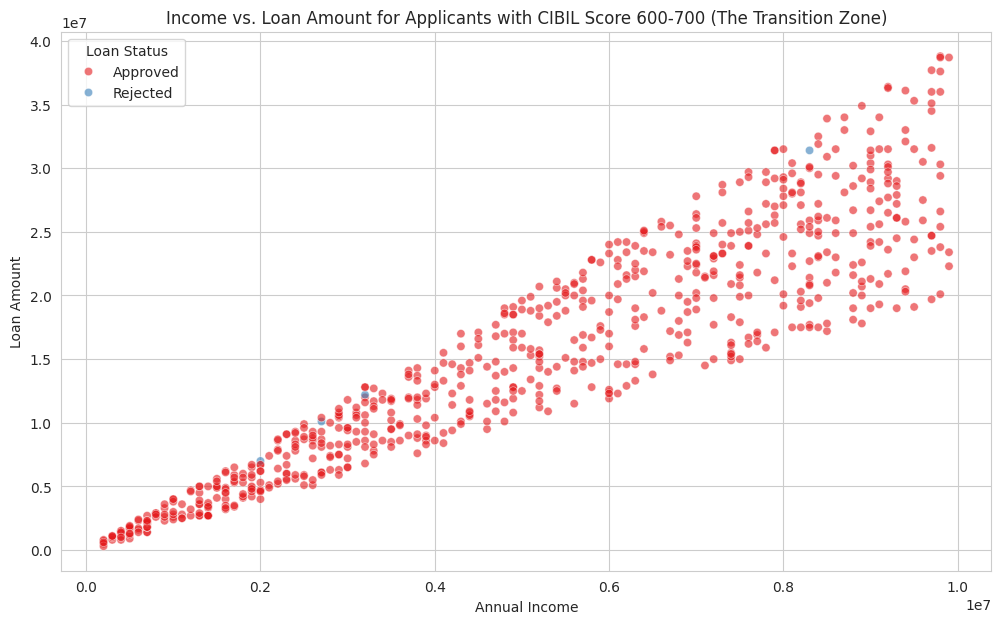


Average values in the Transition Zone (CIBIL 600-700):
             income_annum   loan_amount  cibil_score
loan_status                                         
Approved     5.155983e+06  1.551097e+07   650.232194
Rejected     4.050000e+06  1.517500e+07   679.000000


In [10]:
# Filter the data for the transition zone
transition_df = df[(df['cibil_score'] >= 600) & (df['cibil_score'] < 700)]

# Create a scatter plot of Income vs Loan Amount, colored by loan status
plt.figure(figsize=(12, 7))
sns.scatterplot(data=transition_df, x='income_annum', y='loan_amount', hue='loan_status', alpha=0.6, palette='Set1')
plt.title('Income vs. Loan Amount for Applicants with CIBIL Score 600-700 (The Transition Zone)')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.show()

# Let's also look at the average values for approved vs rejected in this zone
print("\nAverage values in the Transition Zone (CIBIL 600-700):")
print(transition_df.groupby('loan_status')[['income_annum', 'loan_amount', 'cibil_score']].mean())

In [11]:
# Calculate approval rate by Education and CIBIL bracket
edu_approval = df.groupby(['cibil_bracket', 'education'])['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100).unstack()
print("Approval Rate by CIBIL Bracket and Education:\n", edu_approval)

print("\n---\n")
# Calculate approval rate by Self Employed and CIBIL bracket
self_emp_approval = df.groupby(['cibil_bracket', 'self_employed'])['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100).unstack()
print("Approval Rate by CIBIL Bracket and Self-Employed Status:\n", self_emp_approval)

Approval Rate by CIBIL Bracket and Education:
 education       Graduate  Not Graduate
cibil_bracket                         
300-400        11.428571      9.039548
400-500         9.641873     12.312312
500-600        55.801105     48.787062
600-700        99.717514     99.147727
700-800        99.206349     99.719888
800-900        99.109792    100.000000

---

Approval Rate by CIBIL Bracket and Self-Employed Status:
 self_employed         No        Yes
cibil_bracket                      
300-400         9.482759  10.955056
400-500        10.882353  10.955056
500-600        52.150538  52.354571
600-700        99.430199  99.436620
700-800        99.445983  99.465241
800-900        99.711816  99.425287


/tmp/ipykernel_1816/1965151136.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_approval = df.groupby(['cibil_bracket', 'education'])['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100).unstack()
/tmp/ipykernel_1816/1965151136.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self_emp_approval = df.groupby(['cibil_bracket', 'self_employed'])['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100).unstack()


## Prepare Data for Machine Learning

To build a predictive model, we need to convert categorical features into numerical ones. We'll use one-hot encoding for `education` and `self_employed`.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop the 'loan_id' and 'cibil_bracket' as they are not features for prediction
df_model = df.drop(['loan_id', 'cibil_bracket'], axis=1)

# Separate target variable
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

# Encode the target variable (Approved: 1, Rejected: 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Identify categorical features for one-hot encoding
categorical_features = ['education', 'self_employed']

# Create a column transformer for one-hot encoding
# remainder='passthrough' keeps other numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
remaining_features = [col for col in X.columns if col not in categorical_features]
feature_names = list(onehot_features) + remaining_features

# Convert X_processed back to a DataFrame for better readability and future use
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("Shape of X after preprocessing:", X_processed_df.shape)
display(X_processed_df.head())


Shape of X after preprocessing: (4269, 13)


,education_Graduate,education_Not Graduate,self_employed_No,self_employed_Yes,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1.0,0.0,1.0,0.0,2.0,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0
1,0.0,1.0,0.0,1.0,0.0,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0
2,1.0,0.0,1.0,0.0,3.0,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0
3,1.0,0.0,1.0,0.0,3.0,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0
4,0.0,1.0,0.0,1.0,5.0,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0


In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (3415, 13)
X_test shape: (854, 13)
y_train shape: (3415,)
y_test shape: (854,)


Model Accuracy: 0.7354
Model Precision: 0.8255
Model Recall: 0.3808
Model F1-Score: 0.5212

Confusion Matrix:
 [[505  26]
 [200 123]]


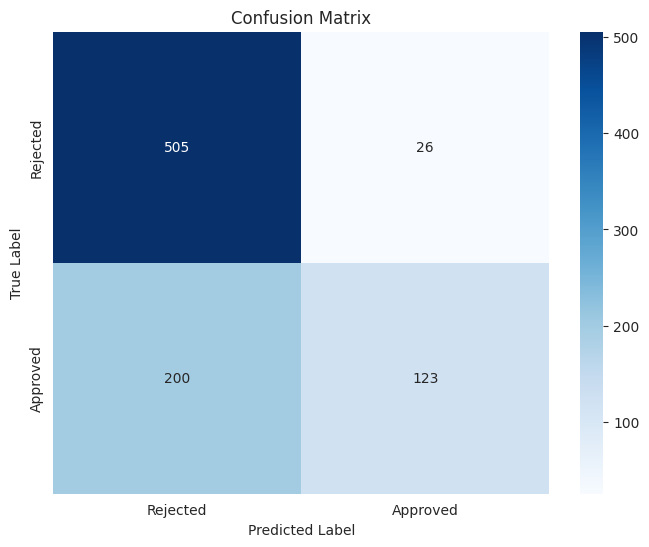

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
